In [4]:
import pandas as pd
import matplotlib.pyplot as plt

cosine_json = 'results/cosine_assignment/metrics/non_iid/class_distributions/class_dist_0_CIFAR10.json'
DPP_json = 'results/DPP/metrics/non_iid/class_distributions/class_dist_2_CIFAR10.json'
proxpref_json = 'results/proxpref/metrics/non_iid/class_distributions/class_dist_0_CIFAR10.json'
cifar10_labels = [
    "Airplane", "Automobile", "Bird", "Cat", "Deer", 
    "Dog", "Frog", "Horse", "Ship", "Truck"
]

In [36]:
import json

with open(proxpref_json, "r") as file:
    data = json.load(file)

rows = []
i =0 
# Process Starting Communities
for _, details in data["Starting Communities"].items():
    row = {"Community": i, "Type": "Starting", "num_clients": details["num_clients"]}
    row.update({f"Class_{cls}": count for cls, count in details["Class_counts"].items()})
    rows.append(row)
    i +=1

i=0
# Process Ending Communities
for _, details in data["Ending_Communities"].items():
    row = {"Community": i, "Type": "Ending", "num_clients": details["num_clients"]}
    row.update({f"Class_{cls}": count for cls, count in details["Class_counts"].items()})
    rows.append(row)
    i +=1

# Convert to DataFrame
df = pd.DataFrame(rows)

# Rename the columns
rename_mapping = {f"Class_{i}": label for i, label in enumerate(cifar10_labels)}
df.rename(columns=rename_mapping, inplace=True)

#normalize distribuitions
class_columns = cifar10_labels
df_norm = df.copy()
df_norm[class_columns] = df_norm[class_columns].div(
    df_norm[class_columns].sum(axis=1), axis=0
) * 100

df_norm.fillna(0, inplace=True)
df_norm[class_columns] = df_norm[class_columns].round(2)


df_norm.head(10)

,Community,Type,num_clients,Ship,Horse,Bird,Truck,Automobile,Deer,Dog,Frog,Cat,Airplane
0,0,Starting,19,21.95,18.80,18.53,8.84,7.54,2.69,2.24,3.67,4.07,11.67
1,1,Starting,20,10.35,3.89,10.75,14.13,15.03,11.80,18.33,3.70,4.45,7.55
2,2,Starting,27,4.48,6.90,16.88,11.70,4.28,8.97,16.86,4.77,10.69,14.47
3,3,Starting,19,6.45,9.52,0.74,10.29,11.48,11.93,11.26,21.53,10.83,5.96
4,4,Starting,15,10.41,11.45,8.08,7.12,11.22,11.78,3.76,10.91,14.58,10.68
5,0,Ending,13,15.10,20.83,2.57,12.61,21.46,0.79,1.32,3.54,3.18,18.61
6,1,Ending,17,7.01,19.12,2.00,6.09,17.62,4.43,5.90,30.22,4.21,3.41
7,2,Ending,16,21.15,4.43,11.07,12.83,5.27,15.05,1.50,8.88,6.16,13.65
8,3,Ending,23,3.67,5.19,16.94,9.68,3.16,9.63,9.41,7.34,22.82,12.17
9,4,Ending,31,7.45,8.63,10.79,9.56,10.20,13.28,20.73,5.02,8.01,6.32


In [14]:
csv_file = "proxpref_class_distribution.csv"
df_norm.to_csv(csv_file, index=False)

print(f"CSV file saved as {csv_file}")

CSV file saved as proxpref_class_distribution.csv


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Split data into starting and ending communities
starting_communities = df_norm[df_norm['Type'] == 'Starting']
ending_communities = df_norm[df_norm['Type'] == 'Ending']

# Function to create a stacked column chart with device count annotations
def plot_stacked_bar_with_devices(data, title, start=True):
    x = np.arange(len(data['Community']))
    class_values = data[cifar10_labels].values.T  # Transpose for stacking
    labels = cifar10_labels
    num_clients = data['num_clients'].values  # Number of devices

    fig, ax = plt.subplots(figsize=(10, 6))
    bottom = np.zeros(len(data['Community']))
    for i, class_label in enumerate(labels):
        ax.bar(x, class_values[i], bottom=bottom, label=class_label)
        bottom += class_values[i]

    # Add device count annotations
    for i, count in enumerate(num_clients):
        ax.text(x[i], bottom[i] + 2, str(int(count)), ha='center', va='bottom', fontsize=9, color='black')

    ax.set_title(title)
    ax.set_xlabel("Community")
    ax.set_ylabel("Percentage")
    ax.set_xticks(x)
    ax.set_xticklabels(data['Community'])
    ax.legend(title="Classes", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.grid(True)
    if start:
        plt.savefig('prox_pref_CIFAR_start.jpeg')
    else:
        plt.savefig('prox_pref_CIFAR_end.jpeg')
    plt.show()

# Plot Starting Communities with device counts
plot_stacked_bar_with_devices(starting_communities, "Class Distribution in Starting Communities with Device Counts")

# Plot Ending Communities with device counts
if not ending_communities.empty:
    plot_stacked_bar_with_devices(ending_communities, "Class Distribution in Ending Communities with Device Counts")
else:
    print("No data available for Ending communities.")

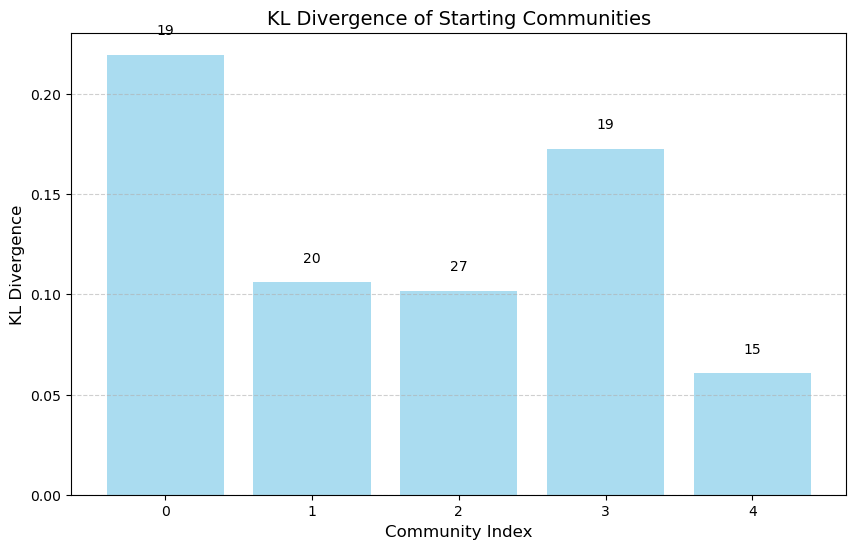

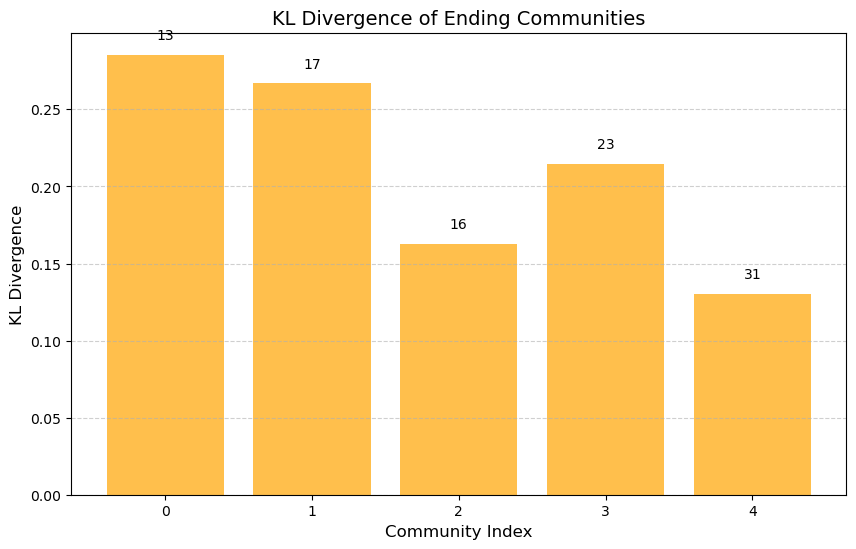

In [37]:
from scipy.special import rel_entr
# Split the data into starting and ending communities
starting_communities = df_norm[df_norm['Type'] == 'Starting'].drop(columns=['Community', 'Type', 'num_clients'])
ending_communities = df_norm[df_norm['Type'] == 'Ending'].drop(columns=['Community', 'Type', 'num_clients'])

# Normalize the distributions to ensure they sum to 1
starting_normalized = starting_communities.div(starting_communities.sum(axis=1), axis=0)
ending_normalized = ending_communities.div(ending_communities.sum(axis=1), axis=0)

#KL divergence
kl_div_starting = starting_normalized.apply(lambda row: rel_entr(row, starting_normalized.mean(axis=0)).sum(), axis=1)

kl_div_ending = ending_normalized.apply(lambda row: rel_entr(row, ending_normalized.mean(axis=0)).sum(), axis=1)

# Plotting the KL divergence for starting communities
plt.figure(figsize=(10, 6))
plt.bar(range(len(kl_div_starting)), kl_div_starting, color='skyblue', alpha=0.7)
plt.title('KL Divergence of Starting Communities', fontsize=14)
plt.xlabel('Community Index', fontsize=12)
plt.ylabel('KL Divergence', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
# Add num_clients on top of each bar
for idx, value in enumerate(kl_div_starting):
    plt.text(idx, value + 0.01, f"{df_norm[df_norm['Type']=='Starting'].iloc[idx]['num_clients']}", ha='center', fontsize=10)
plt.savefig('proxpref_kl_div_starting.jpeg')
plt.show()

# Plotting the KL divergence for ending communities
plt.figure(figsize=(10, 6))
plt.bar(range(len(kl_div_ending)), kl_div_ending, color='orange', alpha=0.7)
plt.title('KL Divergence of Ending Communities', fontsize=14)
plt.xlabel('Community Index', fontsize=12)
plt.ylabel('KL Divergence', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
# Add num_clients on top of each bar
for idx, value in enumerate(kl_div_ending):
    plt.text(idx, value + 0.01, f"{df_norm[df_norm['Type']=='Ending'].iloc[idx]['num_clients']}", ha='center', fontsize=10)
plt.savefig('proxpref_kl_div_ending.jpeg')
plt.show()